### Conversion

Convert, process, and export processed original data to a more structured and useful format (pandas DataFrame).

In [232]:
import importlib
import processing.conversion

importlib.reload(processing.conversion)

from processing.conversion import Conversion

c = Conversion(prefix='processing', subjects=['dwrotheos', 'anestis', 'giannatos'])

c.cleanup_data() # cleans the data directory and prepares for processing
c.process_subjects(replace=False) # processes each subject and exports to txt files

Skipping dwrotheos as raw folder already exists
Skipping anestis as raw folder already exists
Skipping giannatos as raw folder already exists

Processing data for dwrotheos
	Skipping 40.2.mat as it has already been processed
	Skipping 40.3.mat as it has already been processed
	Skipping 40.1.mat as it has already been processed
	Skipping 60.1.mat as it has already been processed
	Skipping 60.2.mat as it has already been processed
	Skipping 60.3.mat as it has already been processed
	Skipping 20.1.mat as it has already been processed
	Skipping 20.3.mat as it has already been processed
	Skipping 20.2.mat as it has already been processed
	Skipping 5.1.mat as it has already been processed
	Skipping 5.3.mat as it has already been processed
	Skipping 5.2.mat as it has already been processed
	Processing MVC.2.mat (MVC: 100, Trial: 2)...
	Processing MVC.1.mat (MVC: 100, Trial: 1)...
	Skipping 10.1.mat as it has already been processed
	Skipping 10.2.mat as it has already been processed
	Skipping 

In [233]:
df = c.get_dataframe() # returns a pandas dataframe of the processed data
df

Loading data for dwrotheos...
Loading data for anestis...
Loading data for giannatos...


,subject,mvc_level,trial_number,neuron_data,force_data
0,dwrotheos,5,1,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.0, 0.0, 0.006100465392304244, -0.0061004653..."
1,dwrotheos,5,2,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.0, -0.006100465392304244, 0.006100465392300..."
2,dwrotheos,5,3,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.0, 0.006100465392300691, 0.0, 0.00610046539..."
3,dwrotheos,10,1,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.0, 0.0, 0.012200930784608488, 0.01220093078..."
4,dwrotheos,10,2,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.0, 0.0, 0.006100465392304244, 0.01220093078..."
5,dwrotheos,10,3,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.0, -0.006100465392304244, 0.0, 0.0061004653..."
6,dwrotheos,20,1,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.0, -0.0488037231384304, -0.0122009307846084..."
7,dwrotheos,20,2,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.0, 0.0, -0.012200930784608488, -0.006100465..."
8,dwrotheos,20,3,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.0, -0.030502326961517667, 0.006100465392304..."
9,dwrotheos,40,1,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.0, -0.006100465392304244, -0.00610046539230..."


### Sanitization

Remove or correct any errors in the data. This includes removing outliers, filling in missing values, and correcting any other errors in the data. Some entries are not recoverable and will be "purged".

More information and specific algorithm implementations can be found [here](https://github.com/paul-bokelman/force-prediction/issues/3).

In [234]:
import importlib
import processing.sanitization
import processing.constants

importlib.reload(processing.sanitization)
importlib.reload(processing.constants)

from processing.sanitization import Sanitization

sanitizer = Sanitization(df=df)
df = sanitizer.sanitize()

Purging entries with insufficient neuron data...
Purged 8 entries with insufficient neuron data. 43 entries remaining.
Computing global statistics...
Invalid neuron data ([0. 0. 0. ... 0. 0. 0.]), skipping...
	Average max activation distance: 4352.162790697675
	Max force data length: 92032
	Max number of neurons: 33
	Max number of activations: 92032
Global statistics computed.
Purging entries with inconsistent neuron data...
Invalid neuron data ([0. 0. 0. ... 0. 0. 0.]), skipping...
Purged 2 entries with inconsistent firing distances
Handling measurement correlation...
	[dwrotheos.5.1] Leading turn: 5.91064453125 | Trailing turn: 36.5341796875
	[dwrotheos.5.1] Flat Region Interval (Inflection Points): (6.88720703125, 33.25439453125)
	[dwrotheos.5.2] Both regions modified -> Skipping
	[dwrotheos.5.3] Both regions modified -> Skipping
	[dwrotheos.10.1] Both regions modified -> Skipping
	[dwrotheos.10.2] Both regions modified -> Skipping
	[dwrotheos.10.3] Leading turn: 6.2578125 | Trailin

In [235]:
sanitizer.show_purged() # all entries removed during sanitization process

,subject,mvc_level,trial_number
12,anestis,60,1
15,anestis,100,1
16,anestis,100,2
29,dwrotheos,60,1
30,dwrotheos,60,2
31,dwrotheos,60,3
32,dwrotheos,100,1
33,dwrotheos,100,2
49,giannatos,100,1
50,giannatos,100,2


### Direct Prediction

Directly predict force given neuron data using LSTM neural networks.

In [236]:
import processing.processing
import prediction.constants

importlib.reload(processing.processing)

model_info = prediction.constants.models['model'] # gather model specific information for training & prediction
processor = processing.processing.Processing(df, model_info) # setup processor for model

Splits: train=32, val=4, test=5
Using default model presets 


In [237]:
import prediction.dpm

importlib.reload(prediction.dpm)

dpm = prediction.dpm.DirectPredictionModel(processor=processor, overwrite=False)
training_history = dpm.optionally_train() # train model if necessary (no saves)

Loading the existing model...
Model is already trained. Skipping training...


In [238]:
# subject_name = 'giannatos'
# mvc_level = 5
# trial_number = 2

subject_name = 'dwrotheos'
mvc_level = 10
trial_number = 2

# subject_name = 'giannatos'
# mvc_level = 60
# trial_number = 2

trial = df[(df['subject'] == subject_name) & (df['mvc_level'] == mvc_level) & (df['trial_number'] == trial_number)].iloc[0]
predicted_force = dpm.predict(trial=trial)
predicted_force = processor.postprocess_prediction(trial, predicted_force) # postprocesses the prediction
print(f"Predicted force: {predicted_force}")

29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step
9708 79981
Predicted force: [0. 0. 0. ... 0. 0. 0.]


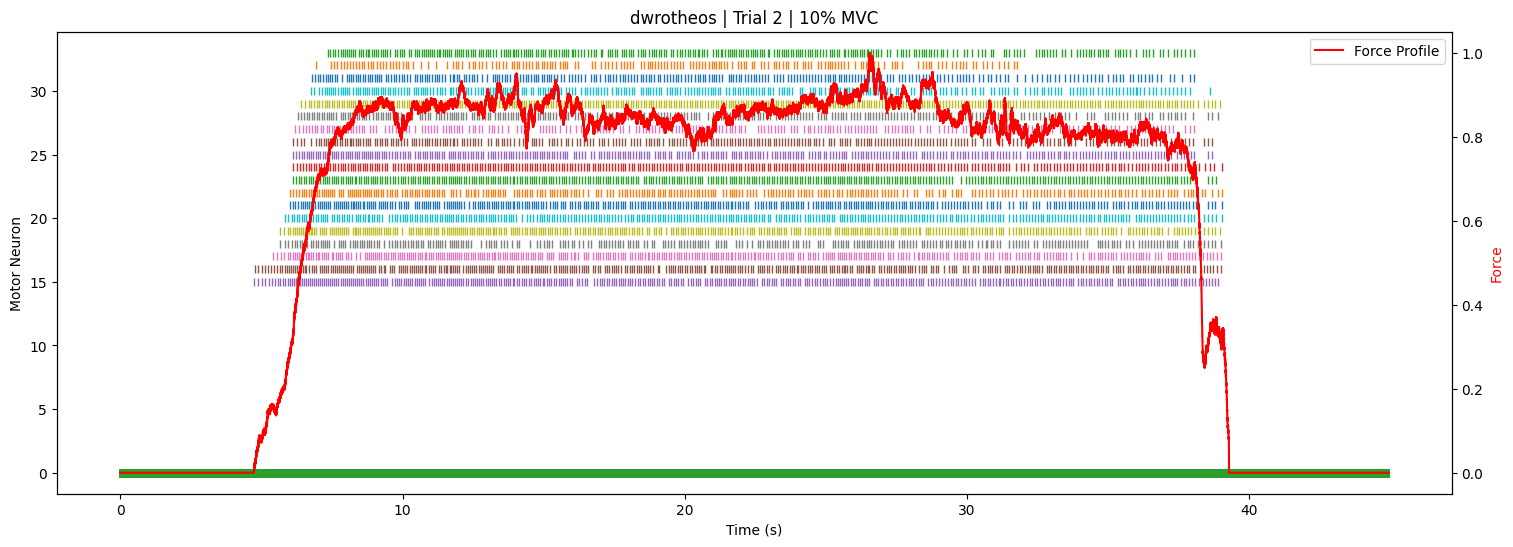

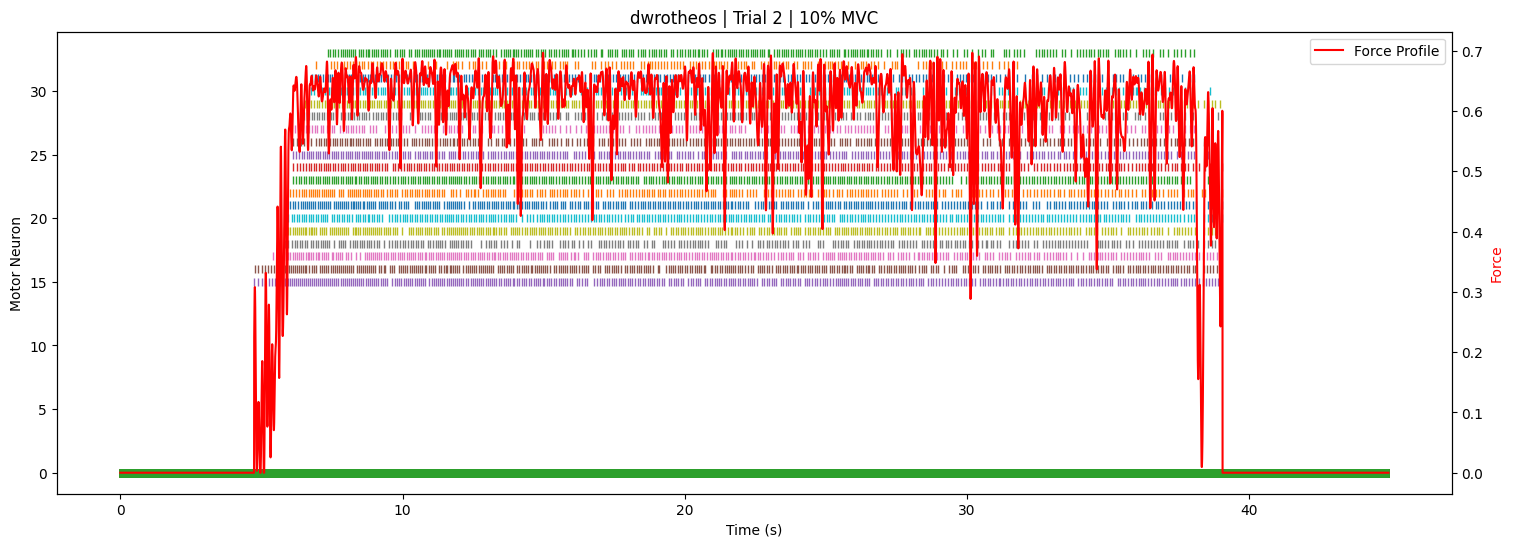

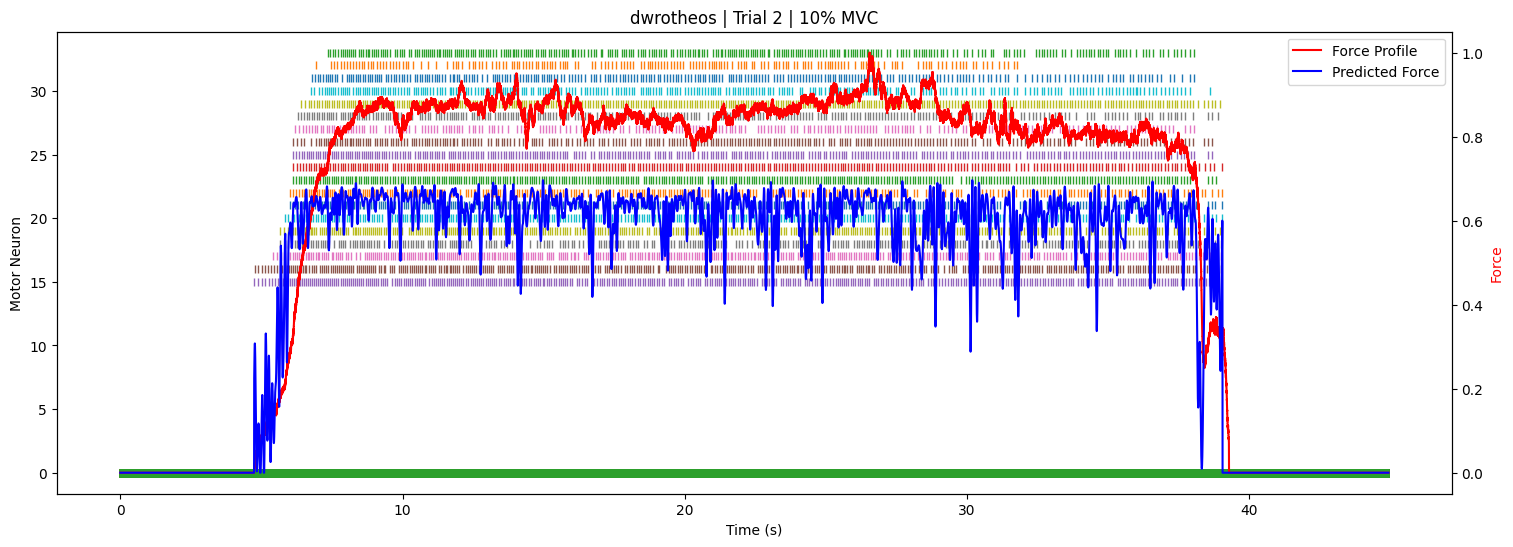

In [239]:
from globals.visualization import visualize_trial

visualize_trial(df, subject=subject_name, mvc_level=mvc_level, trial_number=trial_number,)
visualize_trial(df, subject=subject_name, mvc_level=mvc_level, trial_number=trial_number, force_data=predicted_force)
visualize_trial(df, subject=subject_name, mvc_level=mvc_level, trial_number=trial_number, predicted_force=predicted_force)